# Flipkart Product & Customer Review Analysis

In [6]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import re

In [7]:
# Download the Flipkart dataset from Kaggle

path = kagglehub.dataset_download("niraliivaghani/flipkart-dataset")
print("Dataset path:", path)
os.listdir(path)

Dataset path: C:\Users\ADMIN\.cache\kagglehub\datasets\niraliivaghani\flipkart-dataset\versions\1


['Dataset.csv']

In [8]:
# Create path of the CSV file

file_path = os.path.join(path, "Dataset.csv")
print(file_path)

C:\Users\ADMIN\.cache\kagglehub\datasets\niraliivaghani\flipkart-dataset\versions\1\Dataset.csv


In [11]:
# Load the CSV file

df = pd.read_csv(file_path, encoding="latin1", low_memory=False)

In [10]:
# Display First 5 Rows

df.head()

,Product_name,Price,Rate,Review,Summary
0,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Simply awesome,it's really worth every single penny. it works...
1,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",4,Worth the money . Desert Cooler live up to the...,I bought Crompton Ozone 75 Desert Air Cooler i...
2,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Worth every penny,GREAT packaging by seller. As this was the mos...
3,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Fabulous!,Delivery was delayed by two days except this e...
4,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",4,Nice product,A Good cooler by Crompton. The height of the c...


In [12]:
# Display Last 5 Rows

df.tail()

,Product_name,Price,Rate,Review,Summary
363256,"NIVEA Soft Light Moisturizer for Face, Hand & ...",??142,5,Terrific,Thanks
363257,"NIVEA Soft Light Moisturizer for Face, Hand & ...",??142,5,Terrific,Good
363258,"NIVEA Soft Light Moisturizer for Face, Hand & ...",??142,5,Just wow!,Super
363259,"NIVEA Soft Light Moisturizer for Face, Hand & ...",??142,4,Worth the money,Good
363260,,NaN,NaN,NaN,NaN


In [13]:
# Display Random 5 Rows

df.sample(5)

,Product_name,Price,Rate,Review,Summary
95034,BAJAJ Crest Neo 1200 mm 3 Blade Ceiling Fan??...,"??1,329",4,Nice product,Good one
23490,RIAN Animal Single Mink Blanket for Mild Wint...,??599,5,Classy product,Good
232765,Mivi Fort S24 Soundbar with FM Mode and 2 full...,"??1,999",5,Mind-blowing purchase,Nice
135659,LUMINOUS Power Sine 800 Pure Sine Wave Inverter,"???4,699",1,Utterly Disappointed,this inveter not working low volteg so kindly ...
205701,TP-Link Archer C50 AC1200 Wireless Dual Band 1...,"??1,999",5,Worth every penny,Highly satisfied with this router. I love tpli...


In [14]:
# Check number of rows and columns

print("Rows and Columns:", df.shape)

Rows and Columns: (363261, 5)


In [15]:
# Display column names

print(df.columns)

Index(['Product_name', 'Price', 'Rate', 'Review', 'Summary'], dtype='object')


In [16]:
# Check Data Types

df.dtypes

Product_name    object
Price           object
Rate            object
Review          object
Summary         object
dtype: object

In [17]:
# Check Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363261 entries, 0 to 363260
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Product_name  363246 non-null  object
 1   Price         363245 non-null  object
 2   Rate          363245 non-null  object
 3   Review        363239 non-null  object
 4   Summary       361239 non-null  object
dtypes: object(5)
memory usage: 13.9+ MB


In [18]:
# Count missing values in each column

df.isnull().sum()

Product_name      15
Price             16
Rate              16
Review            22
Summary         2022
dtype: int64

In [19]:
# Check completely identical rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 53786


In [20]:
# Statistical Summary

df.describe()

,Product_name,Price,Rate,Review,Summary
count,363246,363245,363245,363239,361239
unique,1175,709,9,3841,165850
top,Bumtum Baby Pull-Up Diaper Pants Combo Pack - ...,"??4,499",5,Wonderful,Good
freq,9937,12633,203832,18567,25001


#### Data Cleaning

In [21]:
# Remove unnecessary spaces from column names

df.columns = df.columns.str.strip()
print(df.columns)

Index(['Product_name', 'Price', 'Rate', 'Review', 'Summary'], dtype='object')


In [22]:
# Remove unwanted encoding characters from product names

df["Product_name"] = df["Product_name"].astype(str)
df["Product_name"] = df["Product_name"].str.replace(r"[^a-zA-Z0-9\s\(\),&./+\-]","",regex=True)
df["Product_name"] = df["Product_name"].str.strip()
df["Product_name"].head()

0    Crompton 75 L Desert Air Cooler(White, Teal, A...
1    Crompton 75 L Desert Air Cooler(White, Teal, A...
2    Crompton 75 L Desert Air Cooler(White, Teal, A...
3    Crompton 75 L Desert Air Cooler(White, Teal, A...
4    Crompton 75 L Desert Air Cooler(White, Teal, A...
Name: Product_name, dtype: object

In [23]:
# Remove currency symbols, encoding characters and commas

df["Price"] = df["Price"].astype(str)
df["Price"] = df["Price"].str.replace(r"[^0-9,]","",regex=True)
df["Price"] = df["Price"].str.replace(",","",regex=False)

# Convert Price into numeric format
df["Price"] = pd.to_numeric(df["Price"],errors="coerce")
df["Price"].head()

0    10499.0
1    10499.0
2    10499.0
3    10499.0
4    10499.0
Name: Price, dtype: float64

In [24]:
print("Missing Price values:", df["Price"].isnull().sum())

Missing Price values: 19


In [25]:
# Convert ratings into numeric format

df["Rate"] = pd.to_numeric(df["Rate"],errors="coerce")
df["Rate"].unique()

array([ 5.,  4.,  3.,  1.,  2., nan])

In [26]:
# Ratings should be between 1 and 5

df.loc[(df["Rate"] < 1) | (df["Rate"] > 5),"Rate"] = np.nan
print(sorted(df["Rate"].dropna().unique()))

[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


In [27]:
print("Missing Rate values:", df["Rate"].isnull().sum())

Missing Rate values: 22


In [28]:
# Replace missing reviews and clean the text

df["Review"] = df["Review"].fillna("No review")
df["Review"] = df["Review"].astype(str)
df["Review"] = df["Review"].str.strip()
df["Review"] = df["Review"].str.lower()
df["Review"] = df["Review"].str.replace(r"[^a-zA-Z0-9\s]","",regex=True)
df["Review"].head()

0                                       simply awesome
1    worth the money  desert cooler live up to the ...
2                                    worth every penny
3                                             fabulous
4                                         nice product
Name: Review, dtype: object

In [29]:
# Replace missing summaries and clean the text

df["Summary"] = df["Summary"].fillna("No summary")
df["Summary"] = df["Summary"].astype(str)
df["Summary"] = df["Summary"].str.strip()
df["Summary"] = df["Summary"].str.lower()
df["Summary"] = df["Summary"].str.replace(r"[^a-zA-Z0-9\s]","",regex=True)
df["Summary"].head()

0    its really worth every single penny it works l...
1    i bought crompton ozone 75 desert air cooler i...
2    great packaging by seller as this was the most...
3    delivery was delayed by two days except this e...
4    a good cooler by crompton the height of the co...
Name: Summary, dtype: object

In [30]:
# Fill missing prices with the median price

df["Price"] = df["Price"].fillna(df["Price"].median())
print("Missing Price values:", df["Price"].isnull().sum())

Missing Price values: 0


In [31]:
# Fill missing ratings with the median rating

df["Rate"] = df["Rate"].fillna(df["Rate"].median())
print("Missing Rate values:", df["Rate"].isnull().sum())

Missing Rate values: 0


In [32]:
# Permanently remove completely identical records

print("Duplicates before removal:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

# Reset the index after deleting duplicate rows

df.reset_index(drop=True, inplace=True)
print("Duplicates after removal:", df.duplicated().sum())

Duplicates before removal: 63065
Duplicates after removal: 0


In [33]:
# Verify that missing values have been handled

df.isnull().sum()

Product_name    0
Price           0
Rate            0
Review          0
Summary         0
dtype: int64

In [34]:
# Verify that exact duplicate records have been removed

print("Final duplicate rows:", df.duplicated().sum())

Final duplicate rows: 0


In [35]:
# Check final data types

df.dtypes

Product_name     object
Price           float64
Rate            float64
Review           object
Summary          object
dtype: object

In [36]:
# Check the final number of rows and columns

print("Final dataset shape:", df.shape)

Final dataset shape: (300196, 5)


In [37]:
# Display the cleaned dataset

df.head(10)

,Product_name,Price,Rate,Review,Summary
0,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,5.0,simply awesome,its really worth every single penny it works l...
1,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,4.0,worth the money desert cooler live up to the ...,i bought crompton ozone 75 desert air cooler i...
2,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,5.0,worth every penny,great packaging by seller as this was the most...
3,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,5.0,fabulous,delivery was delayed by two days except this e...
4,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,4.0,nice product,a good cooler by crompton the height of the co...
5,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,5.0,super,cant go wrong with crompton brand in punjab th...
6,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,5.0,terrific purchase,a great cooler in great price compact and grea...
7,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,5.0,classy product,its an awesome product and i am not making any...
8,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,5.0,perfect product,air throw is very goodlow noise and best cooli...
9,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,5.0,its not a cooler its ac cooler,its been 6 days that i am using this cooler we...


In [38]:
# Statistical Summary

df.describe()

,Price,Rate
count,300196.000000,300196.000000
mean,4784.490346,3.998484
std,8380.048701,1.388973
min,2.000000,1.000000
25%,489.000000,3.000000
50%,1995.000000,5.000000
75%,5437.000000,5.000000
max,101100.000000,5.000000


In [39]:
# Calculate the average customer rating

average_rating = df["Rate"].mean()
print("Average Rating:", average_rating)

Average Rating: 3.9984843235752643


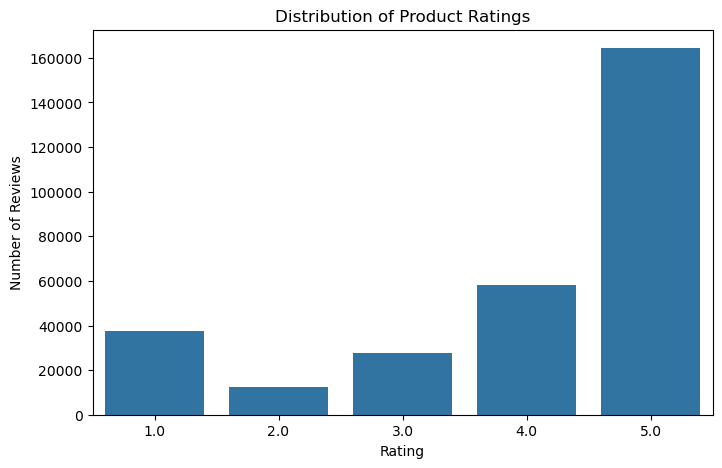

In [41]:
# Count and plot the number of reviews for each rating

rating_counts = df["Rate"].value_counts().sort_index()
rating_counts
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="Rate"
)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

In [42]:
# Find the 10 records with the highest ratings

top_rated = df[
    ["Product_name", "Rate"]
].sort_values(
    by="Rate",
    ascending=False
).head(10)

top_rated

,Product_name,Rate
0,"Crompton 75 L Desert Air Cooler(White, Teal, A...",5.0
167845,"Mi 3i 10000 mAh Power Bank (Fast Charging, 18W...",5.0
167899,"Mi 3i 10000 mAh Power Bank (Fast Charging, 18W...",5.0
167901,"Mi 3i 10000 mAh Power Bank (Fast Charging, 18W...",5.0
167902,"Mi 3i 10000 mAh Power Bank (Fast Charging, 18W...",5.0
167903,"Mi 3i 10000 mAh Power Bank (Fast Charging, 18W...",5.0
167904,"Mi 3i 10000 mAh Power Bank (Fast Charging, 18W...",5.0
167905,"Mi 3i 10000 mAh Power Bank (Fast Charging, 18W...",5.0
167906,"Mi 3i 10000 mAh Power Bank (Fast Charging, 18W...",5.0
167909,"Mi 3i 10000 mAh Power Bank (Fast Charging, 18W...",5.0


In [43]:
# Calculate the correlation between product price and rating
df[["Price", "Rate"]].corr()

,Price,Rate
Price,1.000000,0.006096
Rate,0.006096,1.000000


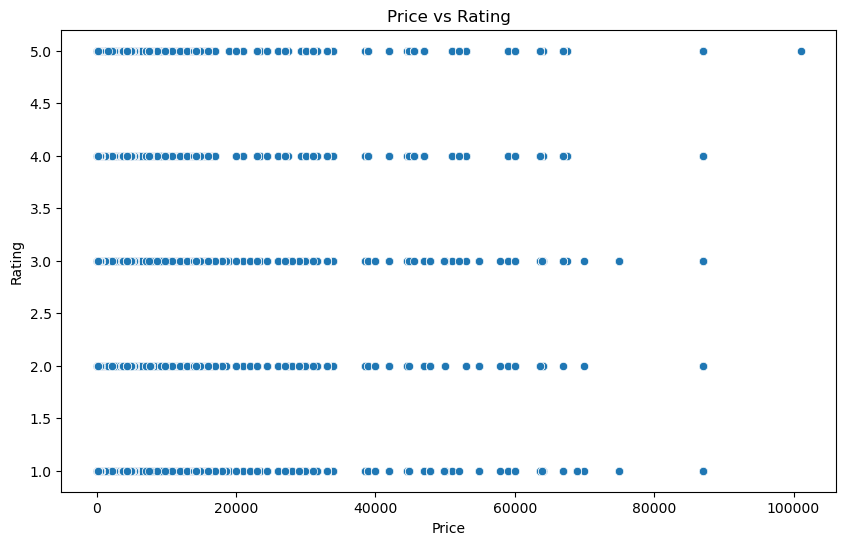

In [44]:
# Price vs Rating Scatter Plot

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Price",
    y="Rate"
)
plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")

plt.show()

In [45]:
# Display statistical information about product prices

df["Price"].describe()

count    300196.000000
mean       4784.490346
std        8380.048701
min           2.000000
25%         489.000000
50%        1995.000000
75%        5437.000000
max      101100.000000
Name: Price, dtype: float64

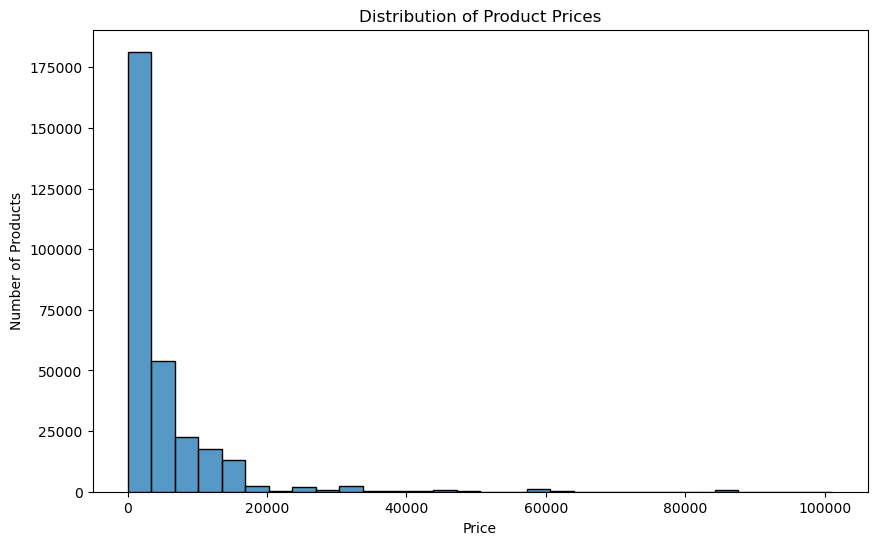

In [46]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="Price",
    bins=30
)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.show()

In [47]:
# Count the number of reviews for each product

most_reviewed = df[
    "Product_name"
].value_counts().head(10)
most_reviewed

Product_name
Bumtum Baby Pull-Up Diaper Pants Combo Pack - L(186 Pieces)                                                            6514
Google Home Mini with Google Assistant Smart Speaker(Charcoal)                                                         6472
cello Pack of 18 Opalware Cello Dazzle Lush Fiesta Opalware Dinner Set, 18 Pieces Dinner Set(White, Microwave Safe)    6411
Mi 5A 80 cm (32 inch) HD Ready LED Smart Android TV with Dolby Audio (2022 Model)                                      6254
MILTON Thermosteel Flip Lid 500 ml Flask(Pack of 1, Silver, Steel)                                                     5461
Lakm Eyeconic Kajal Twin Pack(Deep Black, 0.7 g)                                                                       4600
Crompton 75 L Desert Air Cooler(White, Teal, ACGC-DAC751)                                                              4288
Crompton 88 L Desert Air Cooler with Honeycomb Cooling Pad(White, Teal, ACGC-DAC881)                                   

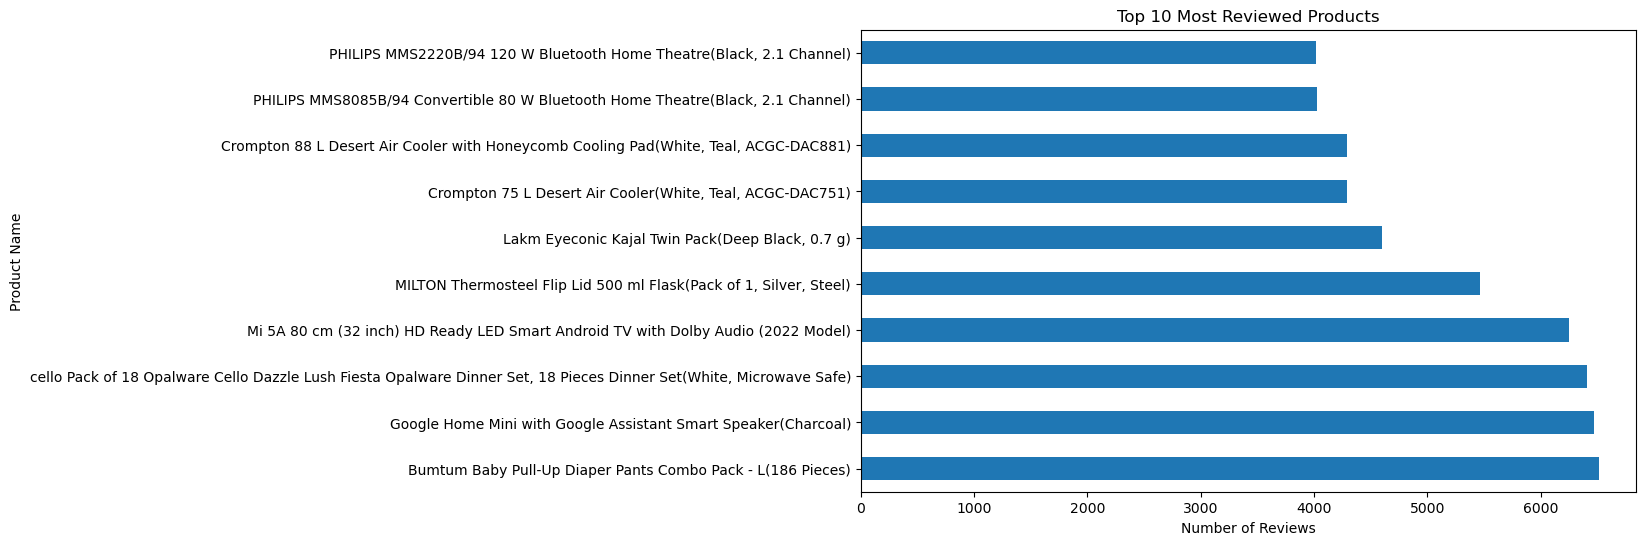

In [48]:
# Most Reviewed Products Graph

plt.figure(figsize=(10, 6))
most_reviewed.plot(
    kind="barh"
)
plt.title("Top 10 Most Reviewed Products")
plt.xlabel("Number of Reviews")
plt.ylabel("Product Name")
plt.show()

In [49]:
# Select reviews with ratings of 2 or below

poor_ratings = df[df["Rate"] <= 2]
print("Number of Poor Ratings:", len(poor_ratings))
poor_ratings[["Product_name", "Rate", "Review"]].head(10)

Number of Poor Ratings: 49809


,Product_name,Rate,Review
12,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,dont waste your money
19,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,unsatisfactory
20,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,utterly disappointed
60,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,unsatisfactory
65,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,did not meet expectations
68,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,dont waste your money
82,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,did not meet expectations
155,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,not recommended at all
156,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,product changed
157,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,item is good but delhivery courier service worst


In [50]:
# Count poor ratings for each product
poor_products = poor_ratings["Product_name"].value_counts().head(10)
poor_products

Product_name
Bumtum Baby Pull-Up Diaper Pants Combo Pack - L(186 Pieces)                                            2208
Google Home Mini with Google Assistant Smart Speaker(Charcoal)                                          969
Ephemeral LCD Writing 8.5 Inch Tablet Electronic Writing & Drawing Doodle Board (GREEN)(Multicolor)     831
Osjs SOFT TOYS LOVER teddy bear pink colors size 3 feet very soft teddy bear  - 90.2 cm(Pink)           744
PHILIPS SPA4040B/94 45 W Bluetooth Home Theatre(Black, 5.1 Channel)                                     693
Crompton 75 L Desert Air Cooler(White, Teal, ACGC-DAC751)                                               653
Crompton 88 L Desert Air Cooler with Honeycomb Cooling Pad(White, Teal, ACGC-DAC881)                    652
Mi 5A 80 cm (32 inch) HD Ready LED Smart Android TV with Dolby Audio (2022 Model)                       622
PHILIPS SPA8140B/94 38 W Bluetooth Home Theatre(Black, 4.1 Channel)                                     611
PHILIPS SPA5128

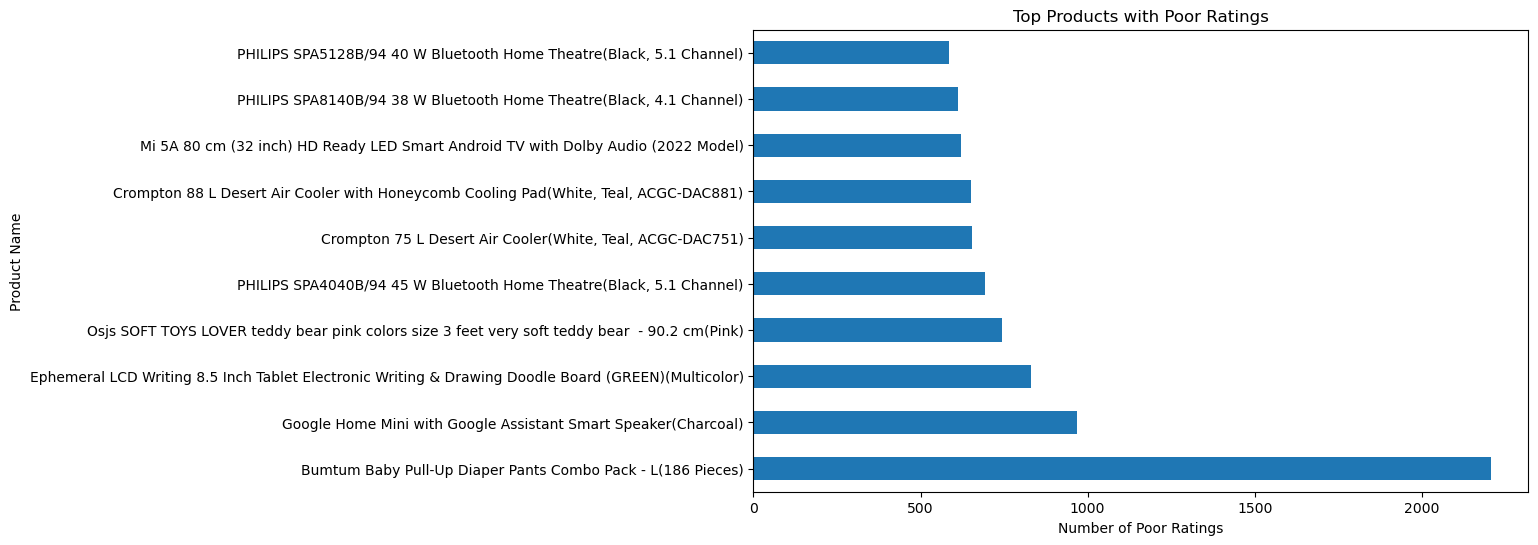

In [51]:
# Poor Ratings Graph

plt.figure(figsize=(10, 6))
poor_products.plot(
    kind="barh"
)
plt.title("Top Products with Poor Ratings")
plt.xlabel("Number of Poor Ratings")
plt.ylabel("Product Name")
plt.show()

In [52]:
# Display some customer reviews with ratings of 2 or below
negative_reviews = df[df["Rate"] <= 2]
negative_reviews[["Product_name", "Rate", "Review"]].head(10)

,Product_name,Rate,Review
12,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,dont waste your money
19,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,unsatisfactory
20,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,utterly disappointed
60,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,unsatisfactory
65,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,did not meet expectations
68,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,dont waste your money
82,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,did not meet expectations
155,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,not recommended at all
156,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,product changed
157,"Crompton 75 L Desert Air Cooler(White, Teal, A...",1.0,item is good but delhivery courier service worst


In [53]:
# Define common words that may indicate customer complaints

complaint_words = [
    "bad",
    "poor",
    "worst",
    "quality",
    "damaged",
    "broken",
    "refund",
    "return",
    "late",
    "delay",
    "defective",
    "disappointed",
    "fake",
    "size",
    "fit"
]

In [54]:
# Count how frequently each complaint word appears in negative reviews

complaint_counts = {}
for word in complaint_words:
    complaint_counts[word] = negative_reviews["Review"].str.contains(word,na=False).sum()
    
complaint_counts = pd.Series(complaint_counts)
complaint_counts = complaint_counts.sort_values(ascending=False)
complaint_counts

disappointed    4651
poor            2864
worst           2677
bad             2263
quality         2260
return             8
damaged            7
size               7
delay              6
fit                5
broken             4
late               3
defective          3
refund             1
fake               1
dtype: int64

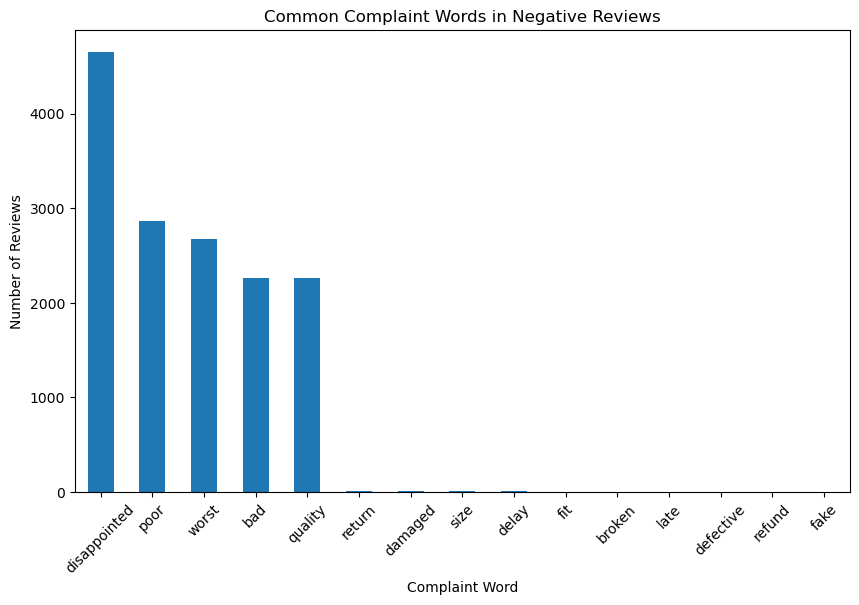

In [55]:
# Common Complaint Words Graph

plt.figure(figsize=(10, 6))
complaint_counts.plot(
    kind="bar"
)
plt.title("Common Complaint Words in Negative Reviews")
plt.xlabel("Complaint Word")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

In [56]:
# Count 5-star reviews

five_star_count = (df["Rate"] == 5).sum()
print("Number of 5-Star Reviews:", five_star_count)

Number of 5-Star Reviews: 164389


In [57]:
# Count 1-star reviews

one_star_count = (df["Rate"] == 1).sum()
print("Number of 1-Star Reviews:", one_star_count)

Number of 1-Star Reviews: 37575


In [58]:
# Calculate the average product price

average_price = df["Price"].mean()
print("Average Product Price:", average_price)

Average Product Price: 4784.49034630708


In [59]:
# Find the 10 cheapest products

cheapest_products = df[["Product_name", "Price", "Rate"]].sort_values(by="Price",ascending=True).head(10)
cheapest_products

,Product_name,Price,Rate
122485,Bajaj DX 2 L/W Dry Iron,2.0,5.0
80191,"Pigeon Favourite Electric Kettle(1.5 L, Silver...",15.0,5.0
81447,Manogyam Soft Comfortable Heel silicone Gel Se...,59.0,4.0
81433,Manogyam Soft Comfortable Heel silicone Gel Se...,59.0,5.0
81432,Manogyam Soft Comfortable Heel silicone Gel Se...,59.0,5.0
81431,Manogyam Soft Comfortable Heel silicone Gel Se...,59.0,4.0
81430,Manogyam Soft Comfortable Heel silicone Gel Se...,59.0,5.0
81429,Manogyam Soft Comfortable Heel silicone Gel Se...,59.0,4.0
81428,Manogyam Soft Comfortable Heel silicone Gel Se...,59.0,4.0
81427,Manogyam Soft Comfortable Heel silicone Gel Se...,59.0,4.0


In [60]:
# Find the 10 most expensive products
expensive_products = df[["Product_name", "Price", "Rate"]].sort_values(by="Price",ascending=False).head(10)
expensive_products

,Product_name,Price,Rate
122494,Nova Plus Amaze NI 10 1100 W Dry Iron(Grey & T...,101100.0,5.0
133101,APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...,86990.0,5.0
132953,APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...,86990.0,5.0
132955,APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...,86990.0,5.0
132956,APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...,86990.0,5.0
132957,APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...,86990.0,5.0
132958,APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...,86990.0,5.0
132959,APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...,86990.0,5.0
132960,APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...,86990.0,5.0
132961,APPLE 2020 Macbook Air M1 - (8 GB/256 GB SSD/M...,86990.0,5.0


In [61]:
print("Final dataset shape:", df.shape)

Final dataset shape: (300196, 5)


In [62]:
print("Final missing values:")
print(df.isnull().sum())

Final missing values:
Product_name    0
Price           0
Rate            0
Review          0
Summary         0
dtype: int64


In [63]:
print("Final duplicate rows:", df.duplicated().sum())

Final duplicate rows: 0


In [64]:
# Display the final cleaned dataset

df.head(10)

,Product_name,Price,Rate,Review,Summary
0,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,5.0,simply awesome,its really worth every single penny it works l...
1,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,4.0,worth the money desert cooler live up to the ...,i bought crompton ozone 75 desert air cooler i...
2,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,5.0,worth every penny,great packaging by seller as this was the most...
3,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,5.0,fabulous,delivery was delayed by two days except this e...
4,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,4.0,nice product,a good cooler by crompton the height of the co...
5,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,5.0,super,cant go wrong with crompton brand in punjab th...
6,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,5.0,terrific purchase,a great cooler in great price compact and grea...
7,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,5.0,classy product,its an awesome product and i am not making any...
8,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,5.0,perfect product,air throw is very goodlow noise and best cooli...
9,"Crompton 75 L Desert Air Cooler(White, Teal, A...",10499.0,5.0,its not a cooler its ac cooler,its been 6 days that i am using this cooler we...


In [65]:
df.to_csv("Flipkart_Customer_Review_Analysis_Cleaned.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
